In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import oggm
from oggm import cfg, utils, workflow
from oggm.core import massbalance
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from scipy.stats import (pearsonr, spearmanr, wilcoxon,
                         kstest, mannwhitneyu)


In [2]:
# Initialize OGGM and set up the working directory
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-mb', reset=True)
cfg.PARAMS['border'] = 10

# Load preprocessed glacier directories
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5/'
gdirs = workflow.init_glacier_directories(['RGI60-06.00291'], from_prepro_level=3, prepro_base_url=base_url)
gdir_kwf = gdirs[0]


2025-04-10 12:50:46: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-04-10 12:50:46: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-04-10 12:50:46: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-04-10 12:50:48: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-04-10 12:50:48: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-04-10 12:50:48: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [3]:

# Read the original mass balance calibration parameters
mb_calib = gdir_kwf.read_json('mb_calib')

# Store original temp_melt
original_temp_melt = cfg.PARAMS['temp_melt']

# Calculate with original parameters
original_params = {
    'melt_f': mb_calib['melt_f'],
    'temp_bias': mb_calib['temp_bias'],
    'prcp_fac': mb_calib['prcp_fac']
}


In [4]:
mbmod_original = massbalance.MonthlyTIModel(gdir_kwf, check_calib_params=False, **original_params)
h, w = gdir_kwf.get_inversion_flowline_hw()
years = np.arange(2000, 2020, 1)  # Adjusted to 2000-2019 (no fractional years)
mbdf = pd.DataFrame(index=years)
mbdf['original_mb'] = mbmod_original.get_specific_mb(h, w, year=mbdf.index)

# Modify parameters
cfg.PARAMS['temp_default_gradient'] = -0.0060
cfg.PARAMS['melt_f'] = 6.6
cfg.PARAMS['temp_melt'] = -1.03


modified_params = {
    'melt_f': 6.6,
    'temp_bias': mb_calib['temp_bias'],
    'prcp_fac': mb_calib['prcp_fac']
}

mbmod_modified = massbalance.MonthlyTIModel(gdir_kwf, check_calib_params=False, **modified_params)
mbdf['modified_mb'] = mbmod_modified.get_specific_mb(h, w, year=mbdf.index)


2025-04-10 12:50:51: oggm.cfg: PARAMS['temp_default_gradient'] changed from `-0.0065` to `-0.006`.
2025-04-10 12:50:51: oggm.cfg: PARAMS['melt_f'] changed from `5.0` to `6.6`.
2025-04-10 12:50:51: oggm.cfg: PARAMS['temp_melt'] changed from `-1.0` to `-1.03`.


In [5]:
# Add Pálsson in situ measurements (only up to 2019)
palsson_data = [-2054, -3092.2, -3569.4, -3572.2, -3971, -2484.4, -2765, -3417.8, 
                -3531, -2602.2, -5636.2, -3066.8, -2041.2, -2114, -3405.8, -1196.8,
                -3386.8, -2824.8, -1467.6, -4639]
mbdf['palsson_mb'] = palsson_data

# Calculate MBE 
def calculate_mbe(observed, modeled):
  
    return np.mean(modeled - observed)

# Calculate MBE and RMSE for original and modified models
mbe_original = calculate_mbe(mbdf['palsson_mb'], mbdf['original_mb'])
mbe_modified = calculate_mbe(mbdf['palsson_mb'], mbdf['modified_mb'])

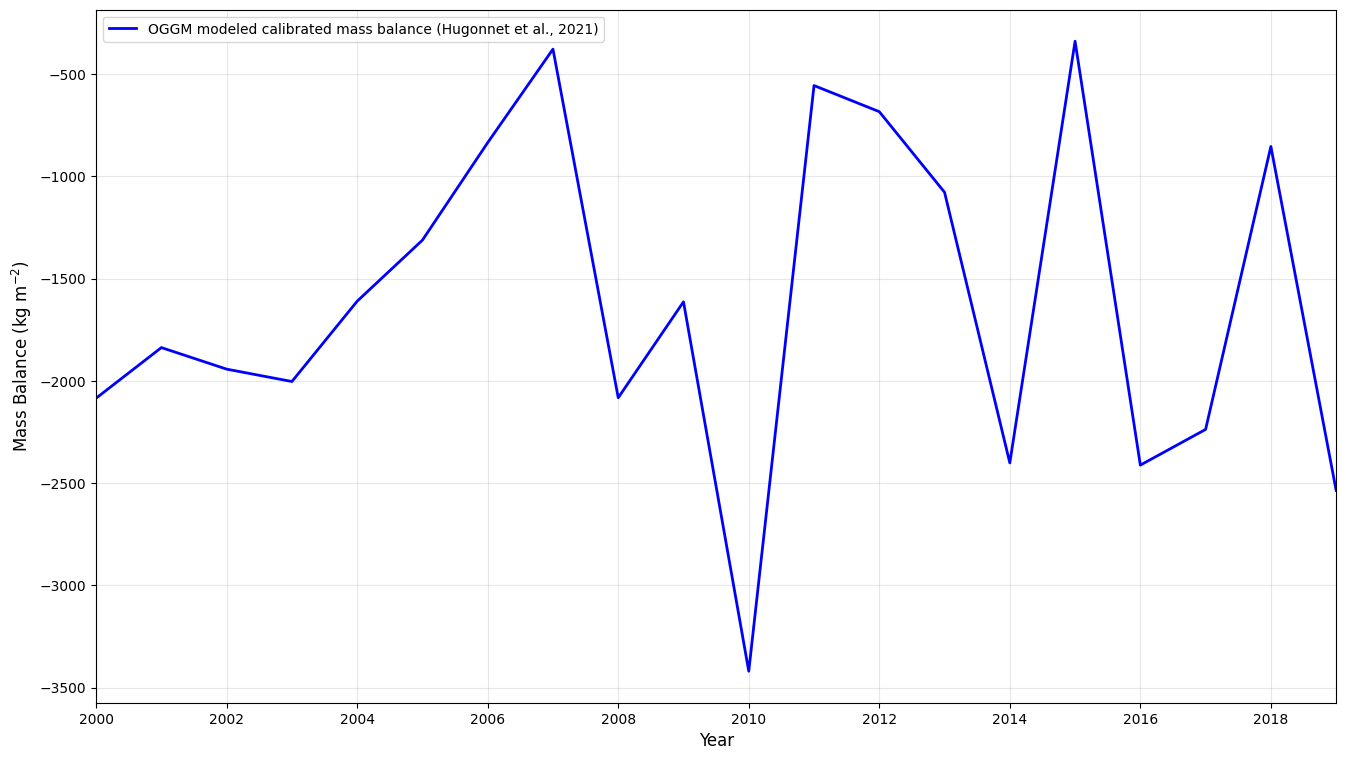

In [6]:

# OGGM Mass balance figure
fig, ax = plt.subplots(figsize=(16, 9))  

# Plot Mass balances  
sns.lineplot(x=mbdf.index, y=mbdf['original_mb'], ax=ax, label='OGGM modeled calibrated mass balance (Hugonnet et al., 2021)', color='blue', linewidth=2)  

# Labels and formatting
ax.set_xlabel('Year', fontsize=12)  
ax.set_ylabel('Mass Balance (kg m$^{-2}$)', fontsize=12)  
ax.legend()  

# Ensure vertical grid lines touch the y-axis
ax.grid(True, alpha=0.3)  # Standard grid (both horizontal and vertical)
ax.yaxis.grid(True, linestyle='-')  # Ensures vertical grid lines

# Ensure first vertical grid line aligns with y-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Ensures integer year ticks
ax.set_xlim([mbdf.index.min(), mbdf.index.max()])  # Adjust x-limits to match data

# Show the plot
plt.show()


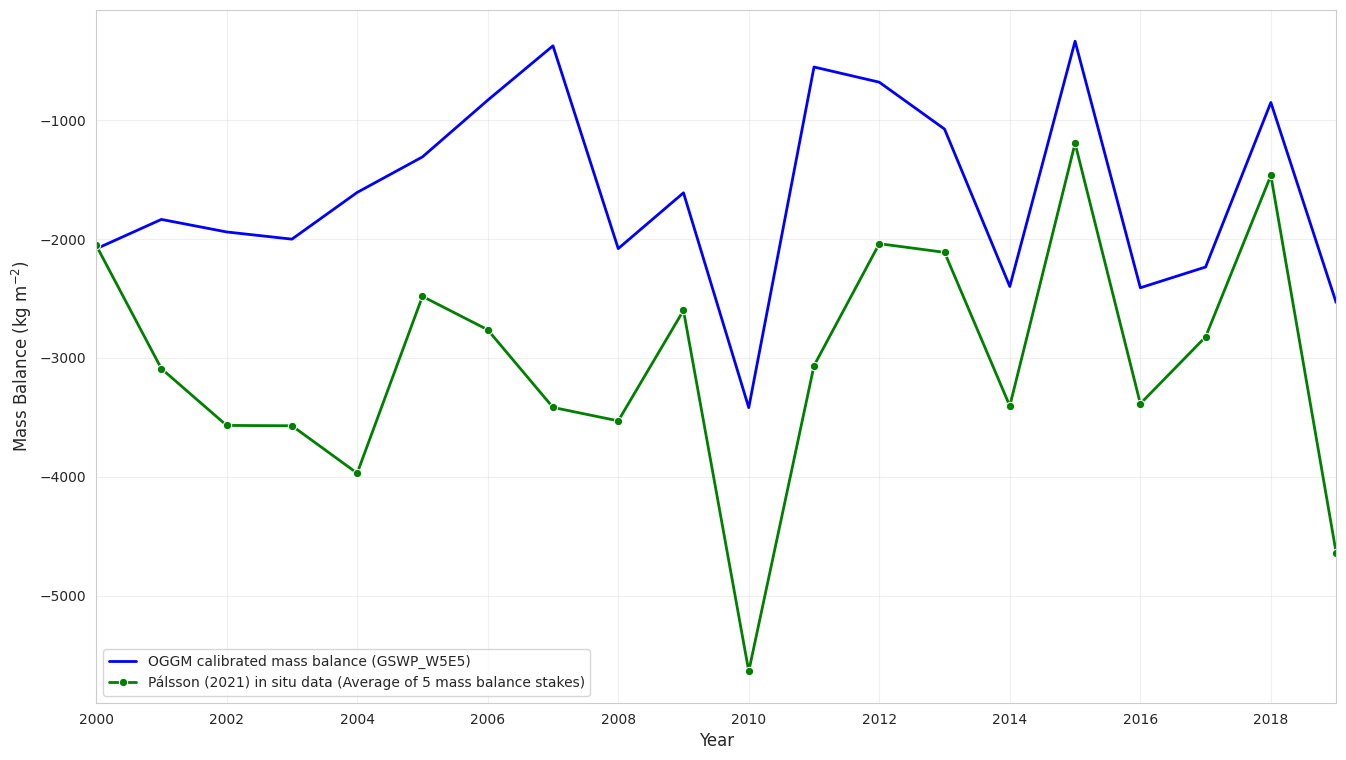

In [7]:

# Set Seaborn style  
sns.set_style("whitegrid")

# Create a single figure
fig, ax = plt.subplots(figsize=(16, 9))  

# Plot Mass balances  
sns.lineplot(x=mbdf.index, y=mbdf['original_mb'], ax=ax, label='OGGM calibrated mass balance (GSWP_W5E5)', color='blue', linewidth=2)  
sns.lineplot(x=mbdf.index, y=mbdf['palsson_mb'], ax=ax, label='Pálsson (2021) in situ data (Average of 5 mass balance stakes)', color='green', linewidth=2, marker='o')  
# Labels and formatting
ax.set_xlabel('Year', fontsize=12)  
ax.set_ylabel('Mass Balance (kg m$^{-2}$)', fontsize=12)  
ax.legend()  

# Ensure vertical grid lines touch the y-axis
ax.grid(True, alpha=0.3)  # Standard grid (both horizontal and vertical)
ax.yaxis.grid(True, linestyle='-')  # Ensures vertical grid lines

# Ensure first vertical grid line aligns with y-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Ensures integer year ticks
ax.set_xlim([mbdf.index.min(), mbdf.index.max()])  # Adjust x-limits to match data

# Show the plot
plt.savefig('figureout/Pálsson_OGGM.png', dpi=300, bbox_inches='tight')
plt.show()


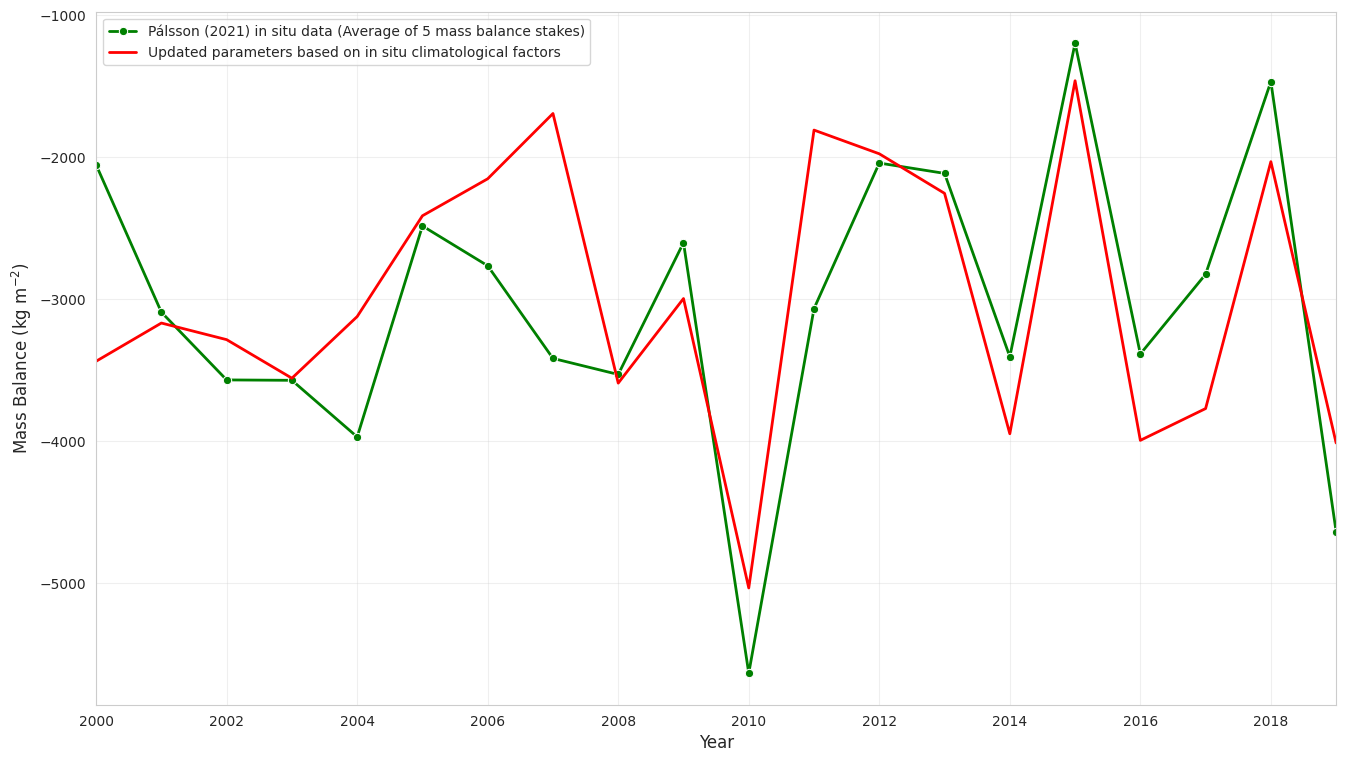

In [8]:

# Set Seaborn style  
sns.set_style("whitegrid")

# Create a single figure
fig, ax = plt.subplots(figsize=(16, 9))  

# Plot Mass balances  

sns.lineplot(x=mbdf.index, y=mbdf['palsson_mb'], ax=ax, label='Pálsson (2021) in situ data (Average of 5 mass balance stakes)', color='green', linewidth=2, marker='o')  
sns.lineplot(x=mbdf.index, y=mbdf['modified_mb'], ax=ax, label='Updated parameters based on in situ climatological factors', color='red', lw=2)
# Labels and formatting
ax.set_xlabel('Year', fontsize=12)  
ax.set_ylabel('Mass Balance (kg m$^{-2}$)', fontsize=12)  
ax.legend()  

# Ensure vertical grid lines touch the y-axis
ax.grid(True, alpha=0.3)  # Standard grid (both horizontal and vertical)
ax.yaxis.grid(True, linestyle='-')  # Ensures vertical grid lines

# Ensure first vertical grid line aligns with y-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
ax.set_xlim([mbdf.index.min(), mbdf.index.max()])  
# Show the plot
plt.savefig('figureout/Pálsson_Params.png', dpi=300, bbox_inches='tight')
plt.show()

2025-04-10 12:52:31: oggm.cfg: PARAMS['melt_f'] changed from `7.7` to `5`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_default_gradient'] changed from `-0.006` to `-0.0065`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `0` to `-1.03`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `-1.03` to `-1.83`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `-1.83` to `0`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_default_gradient'] changed from `-0.0065` to `-0.006`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `0` to `-1.03`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `-1.03` to `-1.83`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `-1.83` to `0`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['melt_f'] changed from `5` to `5.2`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_default_gradient'] changed from `-0.006` to `-0.0065`.
2025-04-10 12:52:31: oggm.cfg: PARAMS['temp_melt'] changed from `

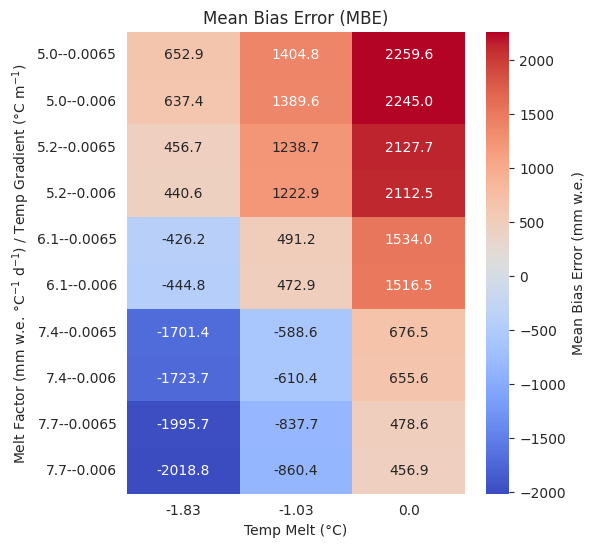

In [10]:
# Define the parameter ranges
melt_f_values = [5, 5.2, 6.1, 7.4, 7.7]
temp_gradient_values = [-0.0065, -0.006]
temp_melt_values = [-1.03, -1.83, 0]

# Palson measurement (in kg m⁻², converted to mm w.e.)
palson_measurement = -3041.9  

# Initialize a DataFrame to store the results
results = []

# Iterate over all combinations of parameters
for melt_f in melt_f_values:
    for temp_gradient in temp_gradient_values:
        for temp_melt in temp_melt_values:
            # Update cfg.PARAMS with the current combination of parameters
            cfg.PARAMS['melt_f'] = melt_f
            cfg.PARAMS['temp_default_gradient'] = temp_gradient
            cfg.PARAMS['temp_melt'] = temp_melt
            
            # Define the modified parameters
            modified_params = {
                'melt_f': melt_f,
                'temp_bias': mb_calib['temp_bias'],
                'prcp_fac': mb_calib['prcp_fac']
            }
            
            # Calculate the mass balance
            mbmod = massbalance.MonthlyTIModel(gdir_kwf, check_calib_params=False, **modified_params)
            h, w = gdir_kwf.get_inversion_flowline_hw()
            years = np.arange(2000, 2020, 1)
            mb = mbmod.get_specific_mb(h, w, year=years).mean()
            
            # Calculate Mean Bias Error (MBE)
            mbe = mb - palson_measurement  # MBE = mean(f_i - y_i)
            
            # Calculate Root Mean Squared Error (RMSE)
            rmse = np.sqrt(np.mean((mb - palson_measurement) ** 2))  # RMSE = sqrt(mean((f_i - y_i)^2))
            
            # Store the results
            results.append({
                'melt_f': melt_f,
                'temp_gradient': temp_gradient,
                'temp_melt': temp_melt,
                'mass_balance': mb,
                'mbe': mbe,
                'rmse': rmse
            })

# Convert the results to a DataFrame
results_df = pd.DataFrame(results)

# Pivot the DataFrame for visualization (MBE)
pivot_mbe = results_df.pivot_table(index=['melt_f', 'temp_gradient'], columns='temp_melt', values='mbe')

# Pivot the DataFrame for visualization (RMSE)
pivot_rmse = results_df.pivot_table(index=['melt_f', 'temp_gradient'], columns='temp_melt', values='rmse')

# Plot the heatmap for MBE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(pivot_mbe, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={'label': 'Mean Bias Error (mm w.e.)'})
plt.title('Mean Bias Error (MBE)')
plt.xlabel('Temp Melt (°C)')
plt.ylabel('Melt Factor (mm w.e. °C$^{-1}$ d$^{-1}$) / Temp Gradient (°C m$^{-1}$)')
plt.savefig('figureout/Params_MBE.png', dpi=300, bbox_inches='tight')